In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


class Linear_Regression():
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):
       
        self.m, self.n = X.shape    
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y


        for i in range(self.no_of_iterations):
            self.update_weights()

    def update_weights(self):
        Y_prediction = self.predict(self.X)


        dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
        db = - 2 * np.sum(self.Y - Y_prediction) / self.m


        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, X):
        return X.dot(self.w) + self.b

In [13]:

chirps_per_min = np.array([
    20.0, 16.0, 19.8, 18.4, 17.1, 15.5, 14.7, 17.1,
    15.4, 16.2, 15.0, 17.2, 16.0, 17.0, 14.4
])

temperature_F = np.array([
    88.6, 71.6, 93.3, 84.3, 80.6, 75.2, 69.7, 82.0,
    69.4, 83.3, 79.6, 82.6, 80.6, 83.5, 76.3
])

df = pd.DataFrame({'chirps_per_min': chirps_per_min, 'temperature_F': temperature_F})
df.head()

,chirps_per_min,temperature_F
0,20.0,88.6
1,16.0,71.6
2,19.8,93.3
3,18.4,84.3
4,17.1,80.6


In [14]:
print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (15, 2)

       chirps_per_min  temperature_F
count           15.00          15.00
mean            16.65          80.04
std              1.70           6.71
min             14.40          69.40
25%             15.45          75.75
50%             16.20          80.60
75%             17.15          83.40
max             20.00          93.30


## Exploratory Data Analysis

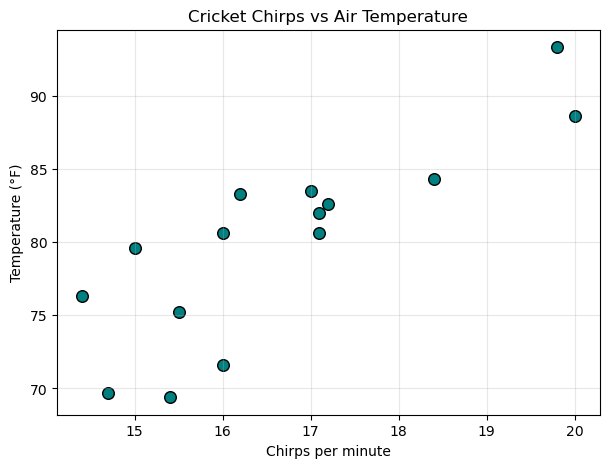

Pearson correlation = 0.835  -> strong positive linear relation


In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(df['chirps_per_min'], df['temperature_F'], color='teal', edgecolor='k', s=70)
plt.xlabel('Chirps per minute')
plt.ylabel('Temperature (°F)')
plt.title('Cricket Chirps vs Air Temperature')
plt.grid(alpha=0.3)
plt.show()

corr = df['chirps_per_min'].corr(df['temperature_F'])
print(f'Pearson correlation = {corr:.3f}  -> strong positive linear relation')

## Train / Test Split

In [16]:
X = df[['chirps_per_min']].values
y = df['temperature_F'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=88)

print('Train size:', len(X_train))
print('Test  size:', len(X_test))

Train size: 10
Test  size: 5


In [17]:
X_mean = X_train.mean()
X_std  = X_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

print(f'Train mean = {X_mean:.2f}, std = {X_std:.2f}')

Train mean = 16.54, std = 1.36


## Train the Model (gradient descent)

In [18]:
model = Linear_Regression(learning_rate=0.05, no_of_iterations=2000)
model.fit(X_train_norm, y_train)

print(f'Weight (normalised space) : {model.w[0]:.3f}')
print(f'Bias   (normalised space) : {model.b:.3f}')

Weight (normalised space) : 3.997
Bias   (normalised space) : 79.500


## Convert Weights Back to Original Units
The model was fitted on standardised `X`, so we map it back:
`y = w * (x - mean)/std + b  ->  y = (w/std) * x + (b - w*mean/std)`.

In [19]:
slope     = model.w[0] / X_std
intercept = model.b - model.w[0] * X_mean / X_std

print(f'Slope     (m): {slope:.3f}')
print(f'Intercept (c): {intercept:.3f}')
print(f'Model: Temp = {slope:.3f} * chirps_per_min + {intercept:.3f}')

Slope     (m): 2.948
Intercept (c): 30.737
Model: Temp = 2.948 * chirps_per_min + 30.737


## Evaluate on the Test Set

In [20]:
y_pred = model.predict(X_test_norm)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R^2  score = {r2:.3f}')
print(f'RMSE       = {rmse:.3f} °F')
print()

comparison = pd.DataFrame({
    'chirps_per_min': X_test.flatten(),
    'actual_temp': y_test.round(1),
    'predicted_temp': y_pred.round(1)
})
comparison

R^2  score = 0.848
RMSE       = 3.084 °F



,chirps_per_min,actual_temp,predicted_temp
0,18.4,84.3,85.0
1,14.4,76.3,73.2
2,14.7,69.7,74.1
3,17.1,82.0,81.2
4,19.8,93.3,89.1


## Visualise the Fit

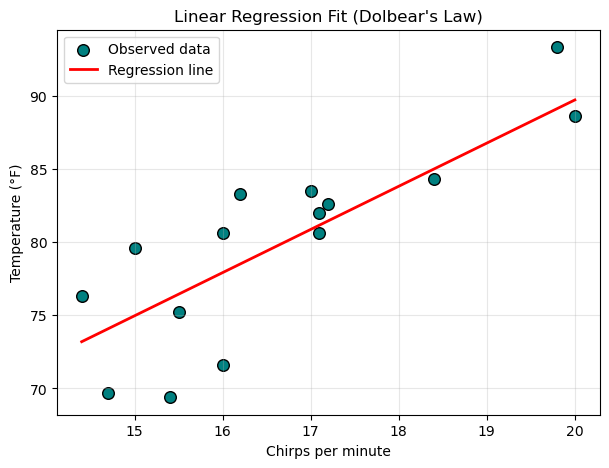

In [21]:

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_norm = (x_line - X_mean) / X_std
y_line = model.predict(x_line_norm)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='teal', edgecolor='k', s=70, label='Observed data')
plt.plot(x_line, y_line, color='red', lw=2, label='Regression line')
plt.xlabel('Chirps per minute')
plt.ylabel('Temperature (°F)')
plt.title("Linear Regression Fit (Dolbear's Law)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Make a Prediction

In [22]:
chirp_input = np.array([[18.0]])
chirp_input_norm = (chirp_input - X_mean) / X_std
predicted_temp = model.predict(chirp_input_norm)[0]
print(f'If a cricket chirps {chirp_input[0][0]:.0f} times/min, predicted temp = {predicted_temp:.1f} °F')

If a cricket chirps 18 times/min, predicted temp = 83.8 °F
